In [ ]:
# =========================
# Parte 1 y 2: Contexto y Preparación de Datos
# =========================
import numpy as np
from sklearn.datasets import load_wine
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


wine_data = load_wine()
# Seleccionar 3 características: Acidez, Color, Magnesio
X = wine_data.data[:, [0, 9, 10]]
# Normalizar entre 0 y 1 (requisito para ART1)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


In [8]:
# =========================
# Parte 3: Implementación de la Red ART
# =========================
class ART:
    def __init__(self, input_dim, theta=0.7, alpha=0.2):
        self.theta = theta  # Umbral de resonancia
        self.alpha = alpha  # Tasa de aprendizaje
        self.input_dim = input_dim
        self.weights = np.zeros((0, input_dim))  # Inicialmente sin neuronas

    def similarity(self, pattern, weight):
        # Similitud de coseno
        return np.dot(pattern, weight) / (np.linalg.norm(pattern) * np.linalg.norm(weight) + 1e-6)

    def match(self, pattern):
        if len(self.weights) == 0:
            return -1
        sims = [self.similarity(pattern, w) for w in self.weights]
        idx = np.argmax(sims)
        if sims[idx] >= self.theta:
            return idx
        return -1

    def train(self, patterns, epochs=1):
        for _ in range(epochs):
            for p in patterns:
                idx = self.match(p)
                if idx == -1:
                    self.weights = np.vstack([self.weights, p])
                else:
                    self.weights[idx] = self.alpha * p + (1 - self.alpha) * self.weights[idx]

    def predict(self, patterns):
        return [self.match(p) for p in patterns]

# =========================
# Parte 4: Clasificación y Aprendizaje
# =========================
art = ART(input_dim=X_scaled.shape[1], theta=0.7, alpha=0.2)
art.train(X_scaled, epochs=5)
predictions = art.predict(X_scaled)

print("Número de categorías detectadas:", len(set(predictions)))
for i, p in enumerate(predictions):
    print(f"Vino {i+1}: Categoría {p}")


Número de categorías detectadas: 2
Vino 1: Categoría 0
Vino 2: Categoría 0
Vino 3: Categoría 0
Vino 4: Categoría 0
Vino 5: Categoría 0
Vino 6: Categoría 0
Vino 7: Categoría 0
Vino 8: Categoría 0
Vino 9: Categoría 0
Vino 10: Categoría 0
Vino 11: Categoría 0
Vino 12: Categoría 0
Vino 13: Categoría 0
Vino 14: Categoría 0
Vino 15: Categoría 0
Vino 16: Categoría 0
Vino 17: Categoría 0
Vino 18: Categoría 0
Vino 19: Categoría 0
Vino 20: Categoría 0
Vino 21: Categoría 0
Vino 22: Categoría 0
Vino 23: Categoría 0
Vino 24: Categoría 0
Vino 25: Categoría 0
Vino 26: Categoría 0
Vino 27: Categoría 0
Vino 28: Categoría 0
Vino 29: Categoría 0
Vino 30: Categoría 0
Vino 31: Categoría 0
Vino 32: Categoría 0
Vino 33: Categoría 0
Vino 34: Categoría 0
Vino 35: Categoría 0
Vino 36: Categoría 0
Vino 37: Categoría 0
Vino 38: Categoría 0
Vino 39: Categoría 0
Vino 40: Categoría 0
Vino 41: Categoría 0
Vino 42: Categoría 0
Vino 43: Categoría 0
Vino 44: Categoría 0
Vino 45: Categoría 0
Vino 46: Categoría 0
Vino 47:


--- Variación de θ ---
θ = 0.6 → Categorías detectadas: 2
θ = 0.7 → Categorías detectadas: 2
θ = 0.85 → Categorías detectadas: 4

--- Variación de α ---
α = 0.1 → Categorías detectadas: 2
α = 0.5 → Categorías detectadas: 2
α = 0.75 → Categorías detectadas: 2


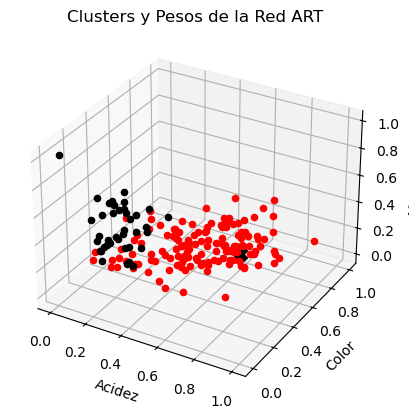

In [9]:
# =========================
# Parte 5: Experimentos y Observaciones
# =========================

# 1. Variación de umbral de resonancia θ
print("\n--- Variación de θ ---")
thetas = [0.6, 0.7, 0.85]
for t in thetas:
    art_temp = ART(input_dim=X_scaled.shape[1], theta=t, alpha=0.2)
    art_temp.train(X_scaled, epochs=5)
    pred_temp = art_temp.predict(X_scaled)
    print(f"θ = {t} → Categorías detectadas: {len(set(pred_temp))}")

# 2. Variación de tasa de aprendizaje α
print("\n--- Variación de α ---")
alphas = [0.1, 0.5, 0.75]
for a in alphas:
    art_temp = ART(input_dim=X_scaled.shape[1], theta=0.7, alpha=a)
    art_temp.train(X_scaled, epochs=5)
    pred_temp = art_temp.predict(X_scaled)
    print(f"α = {a} → Categorías detectadas: {len(set(pred_temp))}")

# 3. Visualización 3D de clusters y pesos
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k']

for i, p in enumerate(predictions):
    ax.scatter(X_scaled[i, 0], X_scaled[i, 1], X_scaled[i, 2],
               color=colors[p % len(colors)], label=f"Cat {p}" if i==0 else "")

# Mostrar pesos de cada categoría
for idx, w in enumerate(art.weights):
    ax.scatter(w[0], w[1], w[2], color='k', marker='X', s=100, label=f"Peso {idx}" if idx==0 else "")

ax.set_xlabel("Acidez")
ax.set_ylabel("Color")
ax.set_zlabel("Magnesio")
plt.title("Clusters y Pesos de la Red ART")
plt.show()